<a href="https://colab.research.google.com/github/morozovsolncev/gravitation/blob/main/Lorentz_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


ЭТАП Г: ОБЪЕДИНЕНИЕ ГРАВИТАЦИИ И ЭЛЕКТРОМАГНЕТИЗМА

Визуализация гравитационного и электромагнитного полей...


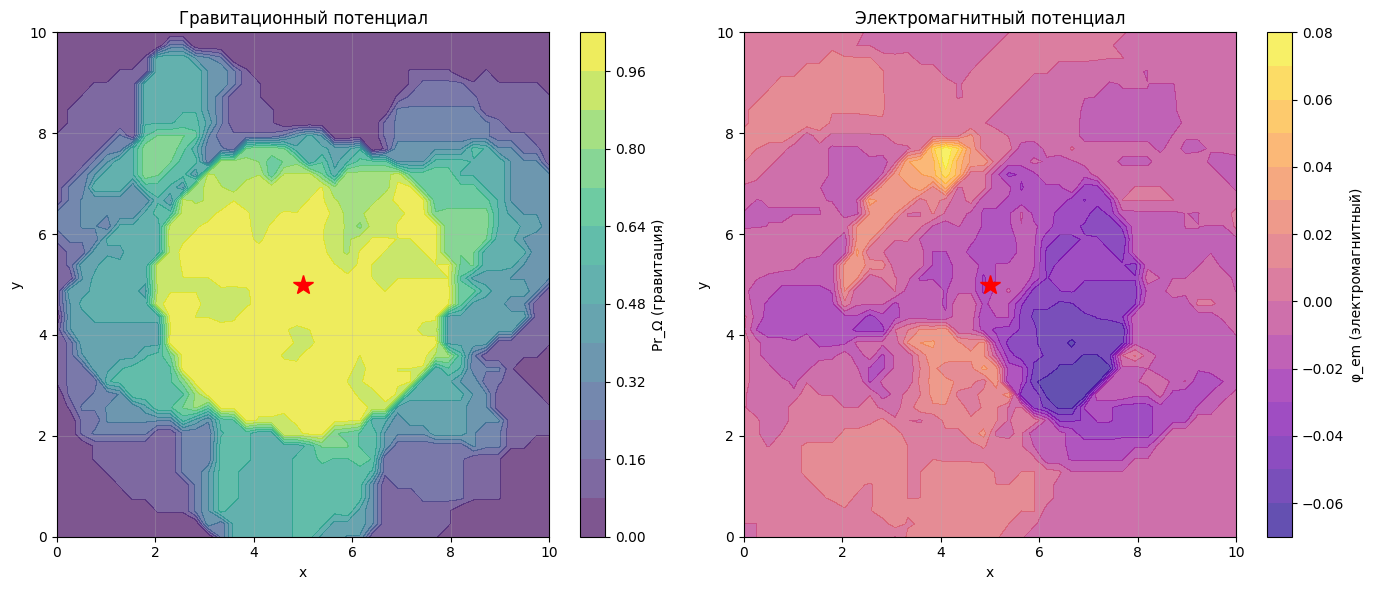


Запуск положительного заряда (+1) с начальной скоростью...
   финальная позиция: (14.76, 20.73)
   финальная скорость: (0.849, 1.183)

Запуск отрицательного заряда (-1) с той же начальной скоростью...
   финальная позиция: (17.41, 13.32)
   финальная скорость: (1.011, 0.482)


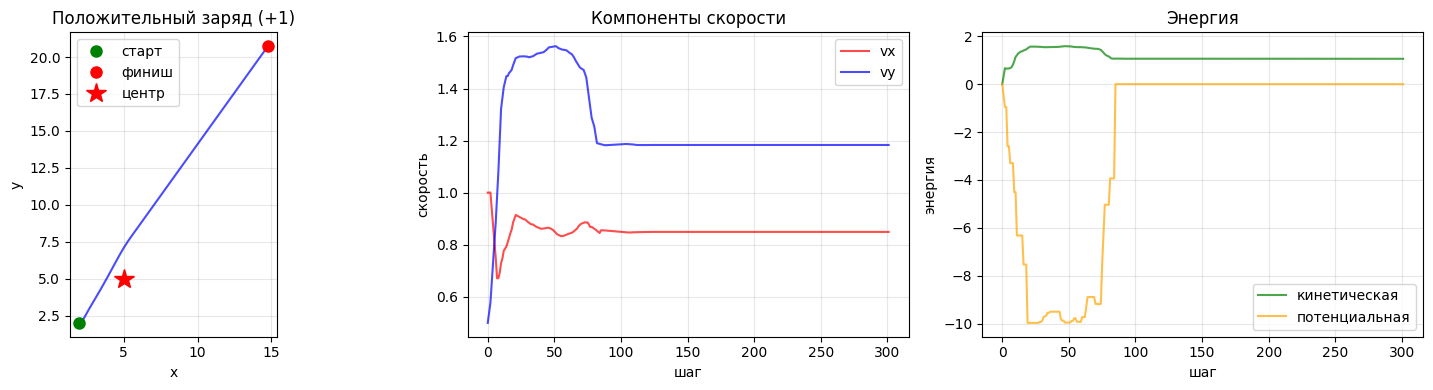

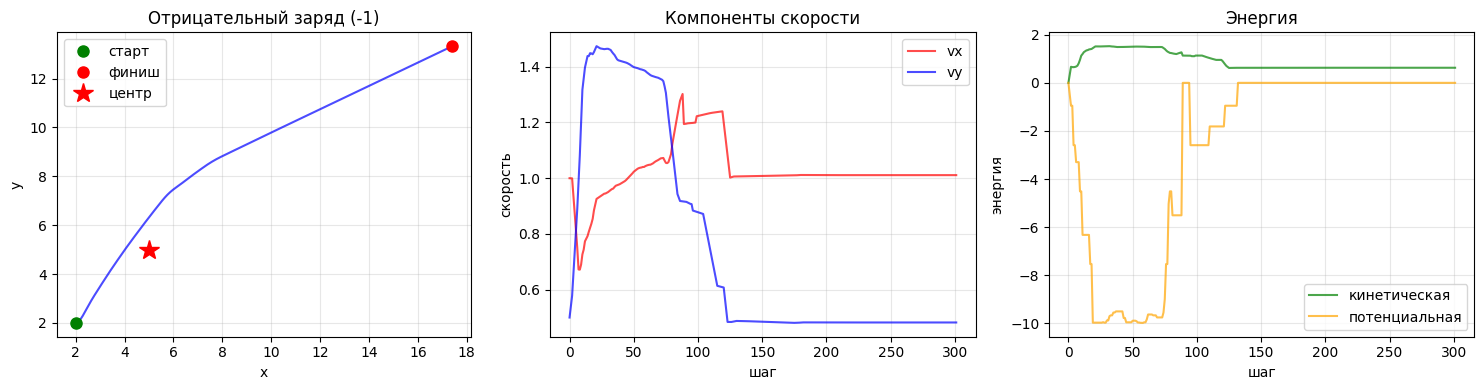

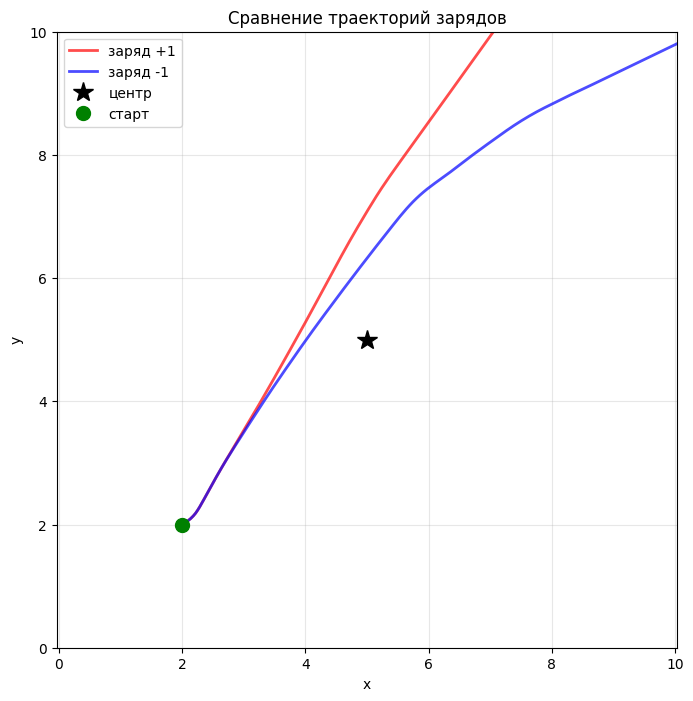


ЭТАП Г ЗАВЕРШЁН


In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
ЭТАП Г: ОБЪЕДИНЕНИЕ ГРАВИТАЦИИ И ЭЛЕКТРОМАГНЕТИЗМА
Движение заряженной частицы в гравитационном поле с асимметрией
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

class UnifiedFieldModel:
    """
    Модель, объединяющая гравитацию (плотность треугольников)
    и электромагнетизм (асимметрию весов)
    """

    def __init__(self, n=50, p_base=0.5, source_mass=20,
                 alpha=0.5, charge_mode='random', eta=1.0, seed=None):

        self.n = n
        self.p_base = p_base
        self.source_mass = source_mass
        self.alpha = alpha
        self.charge_mode = charge_mode
        self.eta = eta  # константа перевода (c^2)

        if seed is not None:
            np.random.seed(seed)

        # Пространство
        self.adj = np.zeros((n, n), dtype=bool)
        self.weights_fwd = np.zeros((n, n), dtype=float)  # i->j
        self.weights_rev = np.zeros((n, n), dtype=float)  # j->i
        self.positions = np.random.rand(n, 2) * 10

        # Источник в центре (вершина 0) с большим зарядом
        self.source_pos = np.array([5.0, 5.0])
        self.positions[0] = self.source_pos

        # Заряды вершин
        self.charges = np.zeros(n)
        self.init_charges()

        # Инициализация графа с неоднородностью
        self.init_graph()

        # Пробная частица
        self.particle_pos = None
        self.particle_vel = None
        self.particle_charge = 1.0  # заряд пробной частицы
        self.particle_history = {'x': [], 'y': [], 'vx': [], 'vy': [],
                                 'step': [], 'Ek': [], 'Ep': []}

    def init_charges(self):
        """Инициализация зарядов вершин"""
        if self.charge_mode == 'random':
            # Случайные заряды +1 или -1
            self.charges = np.random.choice([-1, 1], self.n)
        elif self.charge_mode == 'fixed':
            # Все +1
            self.charges = np.ones(self.n)
        elif self.charge_mode == 'dipole':
            # Диполь: центр +10, остальные случайно
            self.charges = np.random.choice([-1, 1], self.n)
            self.charges[0] = 10  # сильный положительный заряд в центре

    def degree(self, v):
        """Степень вершины"""
        return np.sum(self.adj[v])

    def calculate_asymmetric_weight(self, i, j):
        """Асимметричный вес с учётом зарядов"""
        deg_i = self.degree(i)
        deg_j = self.degree(j)
        base_weight = (deg_i * deg_j) / (self.n * self.n)

        # Асимметрия от зарядов
        charge_product = self.charges[i] * self.charges[j]

        w_fwd = base_weight * (1 + self.alpha * charge_product)
        w_rev = base_weight * (1 - self.alpha * charge_product)

        # Ограничиваем
        w_fwd = max(0.01, min(1.0, w_fwd))
        w_rev = max(0.01, min(1.0, w_rev))

        return w_fwd, w_rev

    def init_graph(self):
        """Создание графа с неоднородной плотностью"""
        for i in range(self.n):
            for j in range(i+1, self.n):
                dist = np.linalg.norm(self.positions[i] - self.positions[j])
                prob = self.p_base * np.exp(-dist / 5)

                # Повышенная плотность у источника
                if i == 0 or j == 0:
                    prob *= self.source_mass

                if np.random.random() < prob:
                    self.adj[i][j] = self.adj[j][i] = True
                    w_fwd, w_rev = self.calculate_asymmetric_weight(i, j)
                    self.weights_fwd[i][j] = w_fwd
                    self.weights_rev[j][i] = w_fwd
                    self.weights_fwd[j][i] = w_rev
                    self.weights_rev[i][j] = w_rev

    def count_triangles_near(self, pos, radius=3):
        """Плотность треугольников (гравитация)"""
        nearby = []
        for i in range(self.n):
            dist = np.linalg.norm(self.positions[i] - pos)
            if dist < radius:
                nearby.append(i)

        triangles = 0
        for i in nearby:
            for j in nearby:
                if i < j and self.adj[i][j]:
                    for k in nearby:
                        if j < k and self.adj[i][k] and self.adj[j][k]:
                            triangles += 1
        return triangles

    def circulation_near(self, pos, radius=3):
        """
        Циркуляция асимметрии в окрестности (магнитное поле)
        Сумма (w_fwd - w_rev) по замкнутым путям
        """
        nearby = []
        for i in range(self.n):
            dist = np.linalg.norm(self.positions[i] - pos)
            if dist < radius:
                nearby.append(i)

        circulation = 0.0
        for i in nearby:
            for j in nearby:
                if i < j and self.adj[i][j]:
                    # Разность прямого и обратного веса
                    circulation += (self.weights_fwd[i][j] - self.weights_rev[i][j])
        return circulation

    def probability_of_resonance(self, pos, radius=3):
        """Вероятность резонанса Pr_Ω (гравитационный потенциал)"""
        rho = self.count_triangles_near(pos, radius)
        # Pr_Ω = exp(-1/ρ) с насыщением
        if rho > 0:
            return 1.0 - np.exp(-rho / 10)
        return 0.0

    def electromagnetic_potential(self, pos, radius=3):
        """Электромагнитный потенциал (от асимметрии)"""
        circ = self.circulation_near(pos, radius)
        # Потенциал пропорционален циркуляции
        return circ / 10

    def total_force(self, pos, vel, charge):
        """
        Полная сила: гравитация + электромагнетизм (сила Лоренца)

        F_grav = (η/2) * ∇[ln Pr_Ω]
        F_em = charge * (E + v × B)

        где E = -∇φ_em, B = ∇ × A (упрощённо)
        """
        delta = 0.2
        x, y = pos

        # --- Гравитационная часть ---
        Pr0 = self.probability_of_resonance([x, y])

        if Pr0 > 0:
            # Градиент логарифма Pr_Ω
            Pr_x_plus = self.probability_of_resonance([x + delta, y])
            Pr_x_minus = self.probability_of_resonance([x - delta, y])
            Pr_y_plus = self.probability_of_resonance([x, y + delta])
            Pr_y_minus = self.probability_of_resonance([x, y - delta])

            dlnP_dx = (np.log(Pr_x_plus) - np.log(Pr_x_minus)) / (2 * delta) if Pr_x_plus > 0 and Pr_x_minus > 0 else 0
            dlnP_dy = (np.log(Pr_y_plus) - np.log(Pr_y_minus)) / (2 * delta) if Pr_y_plus > 0 and Pr_y_minus > 0 else 0

            F_grav = (self.eta / 2) * np.array([dlnP_dx, dlnP_dy])
        else:
            F_grav = np.array([0.0, 0.0])

        # --- Электромагнитная часть ---
        # Электрическое поле E = -∇φ_em
        phi0 = self.electromagnetic_potential([x, y])
        phi_x_plus = self.electromagnetic_potential([x + delta, y])
        phi_x_minus = self.electromagnetic_potential([x - delta, y])
        phi_y_plus = self.electromagnetic_potential([x, y + delta])
        phi_y_minus = self.electromagnetic_potential([x, y - delta])

        E_x = -(phi_x_plus - phi_x_minus) / (2 * delta)
        E_y = -(phi_y_plus - phi_y_minus) / (2 * delta)
        E = np.array([E_x, E_y])

        # Магнитное поле B (упрощённо — скаляр, перпендикулярное к плоскости)
        # В 2D сила Лоренца: v × B даёт поворот на 90°
        circ = self.circulation_near([x, y])
        B = circ / 5  # пропорционально циркуляции

        # Сила Лоренца: F_L = q * (v × B)
        # В 2D: (vx, vy) × B = (vy * B, -vx * B)
        v_cross_B = np.array([vel[1] * B, -vel[0] * B])

        F_em = charge * (E + v_cross_B)

        # Полная сила
        F_total = F_grav + F_em

        return F_total, F_grav, F_em

    def particle_step(self):
        """Один шаг движения"""
        if self.particle_pos is None or self.particle_vel is None:
            return

        F_total, F_grav, F_em = self.total_force(
            self.particle_pos,
            self.particle_vel,
            self.particle_charge
        )

        # Обновление скорости и позиции (Эйлер)
        dt = 0.05
        self.particle_vel += F_total * dt
        self.particle_pos += self.particle_vel * dt

        # Энергии (для истории)
        Ek = 0.5 * np.sum(self.particle_vel**2)
        Ep = -self.probability_of_resonance(self.particle_pos) * 10  # потенциал

        # Сохраняем
        self.particle_history['x'].append(float(self.particle_pos[0]))
        self.particle_history['y'].append(float(self.particle_pos[1]))
        self.particle_history['vx'].append(float(self.particle_vel[0]))
        self.particle_history['vy'].append(float(self.particle_vel[1]))
        self.particle_history['Ek'].append(Ek)
        self.particle_history['Ep'].append(Ep)
        self.particle_history['step'].append(len(self.particle_history['x']))

    def run_particle(self, start_pos, start_vel=None, charge=1.0, steps=500):
        """Запуск частицы"""
        self.particle_pos = np.array([float(start_pos[0]), float(start_pos[1])])
        if start_vel is None:
            self.particle_vel = np.array([0.0, 0.0])
        else:
            self.particle_vel = np.array([float(start_vel[0]), float(start_vel[1])])
        self.particle_charge = charge

        self.particle_history = {
            'x': [self.particle_pos[0]],
            'y': [self.particle_pos[1]],
            'vx': [self.particle_vel[0]],
            'vy': [self.particle_vel[1]],
            'Ek': [0.0],
            'Ep': [0.0],
            'step': [0]
        }

        for _ in range(steps):
            self.particle_step()

        return self.particle_history

    def plot_fields(self):
        """Визуализация гравитационного и электромагнитного полей"""
        x = np.linspace(0, 10, 40)
        y = np.linspace(0, 10, 40)
        X, Y = np.meshgrid(x, y)

        Z_grav = np.zeros_like(X)
        Z_em = np.zeros_like(X)

        for i in range(len(x)):
            for j in range(len(y)):
                Z_grav[j, i] = self.probability_of_resonance([X[j, i], Y[j, i]])
                Z_em[j, i] = self.electromagnetic_potential([X[j, i], Y[j, i]])

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1)
        plt.contourf(X, Y, Z_grav, levels=15, cmap='viridis', alpha=0.7)
        plt.colorbar(label='Pr_Ω (гравитация)')
        plt.plot(self.source_pos[0], self.source_pos[1], 'r*', markersize=15, label='источник')
        plt.xlim(0, 10)
        plt.ylim(0, 10)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Гравитационный потенциал')
        plt.grid(True, alpha=0.3)

        plt.subplot(1, 2, 2)
        plt.contourf(X, Y, Z_em, levels=15, cmap='plasma', alpha=0.7)
        plt.colorbar(label='φ_em (электромагнитный)')
        plt.plot(self.source_pos[0], self.source_pos[1], 'r*', markersize=15, label='источник')
        plt.xlim(0, 10)
        plt.ylim(0, 10)
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Электромагнитный потенциал')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_trajectory(self, history, title='Траектория'):
        """Визуализация траектории"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Траектория
        ax = axes[0]
        ax.plot(history['x'], history['y'], 'b-', linewidth=1.5, alpha=0.7)
        ax.plot(history['x'][0], history['y'][0], 'go', markersize=8, label='старт')
        ax.plot(history['x'][-1], history['y'][-1], 'ro', markersize=8, label='финиш')
        ax.plot(self.source_pos[0], self.source_pos[1], 'r*', markersize=15, label='центр')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_title(title)
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend()

        # Скорость
        ax = axes[1]
        steps = history['step']
        ax.plot(steps, history['vx'], 'r-', label='vx', alpha=0.7)
        ax.plot(steps, history['vy'], 'b-', label='vy', alpha=0.7)
        ax.set_xlabel('шаг')
        ax.set_ylabel('скорость')
        ax.set_title('Компоненты скорости')
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Энергия
        ax = axes[2]
        ax.plot(steps, history['Ek'], 'g-', label='кинетическая', alpha=0.7)
        ax.plot(steps, history['Ep'], 'orange', label='потенциальная', alpha=0.7)
        ax.set_xlabel('шаг')
        ax.set_ylabel('энергия')
        ax.set_title('Энергия')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


# ============================================================
# ЭКСПЕРИМЕНТ Г1: СРАВНЕНИЕ ЗАРЯДОВ
# ============================================================

print("\n" + "="*70)
print("ЭТАП Г: ОБЪЕДИНЕНИЕ ГРАВИТАЦИИ И ЭЛЕКТРОМАГНЕТИЗМА")
print("="*70)

# Создаём модель с диполем в центре
model = UnifiedFieldModel(
    n=50, p_base=0.5, source_mass=20,
    alpha=0.7, charge_mode='dipole', eta=1.0, seed=42
)

# Визуализируем поля
print("\nВизуализация гравитационного и электромагнитного полей...")
model.plot_fields()

# Запускаем частицы с разными зарядами
print("\nЗапуск положительного заряда (+1) с начальной скоростью...")
hist_pos = model.run_particle([2, 2], start_vel=[1.0, 0.5], charge=1.0, steps=300)
print(f"   финальная позиция: ({hist_pos['x'][-1]:.2f}, {hist_pos['y'][-1]:.2f})")
print(f"   финальная скорость: ({hist_pos['vx'][-1]:.3f}, {hist_pos['vy'][-1]:.3f})")

print("\nЗапуск отрицательного заряда (-1) с той же начальной скоростью...")
hist_neg = model.run_particle([2, 2], start_vel=[1.0, 0.5], charge=-1.0, steps=300)
print(f"   финальная позиция: ({hist_neg['x'][-1]:.2f}, {hist_neg['y'][-1]:.2f})")
print(f"   финальная скорость: ({hist_neg['vx'][-1]:.3f}, {hist_neg['vy'][-1]:.3f})")

# Визуализация траекторий
model.plot_trajectory(hist_pos, 'Положительный заряд (+1)')
model.plot_trajectory(hist_neg, 'Отрицательный заряд (-1)')

# Сравнение траекторий
plt.figure(figsize=(8, 8))
plt.plot(hist_pos['x'], hist_pos['y'], 'r-', linewidth=2, label='заряд +1', alpha=0.7)
plt.plot(hist_neg['x'], hist_neg['y'], 'b-', linewidth=2, label='заряд -1', alpha=0.7)
plt.plot(model.source_pos[0], model.source_pos[1], 'k*', markersize=15, label='центр')
plt.plot(hist_pos['x'][0], hist_pos['y'][0], 'go', markersize=10, label='старт')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение траекторий зарядов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.show()

print("\n" + "="*70)
print("ЭТАП Г ЗАВЕРШЁН")
print("="*70)